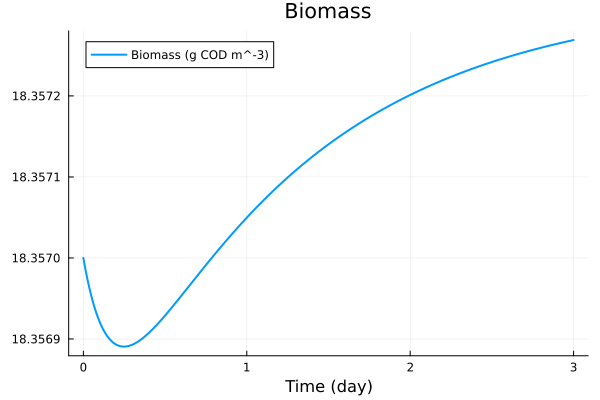

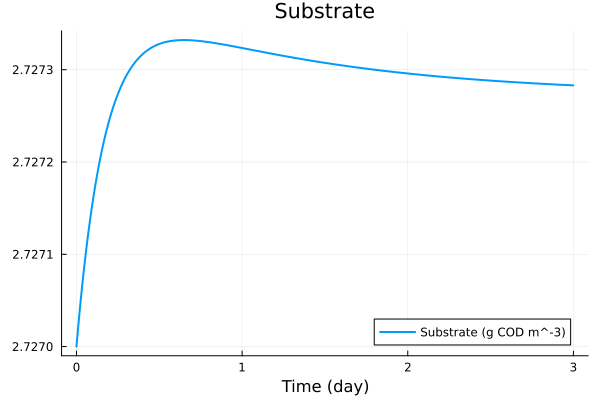

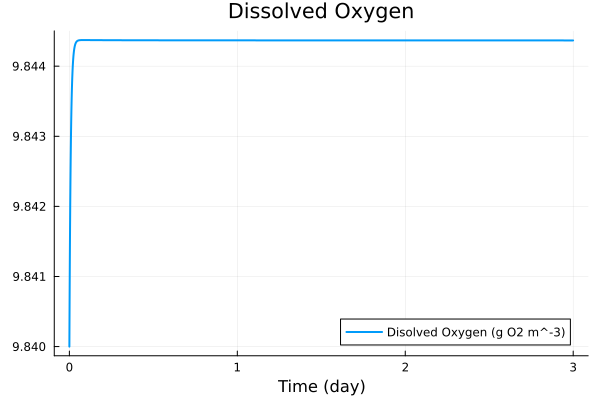

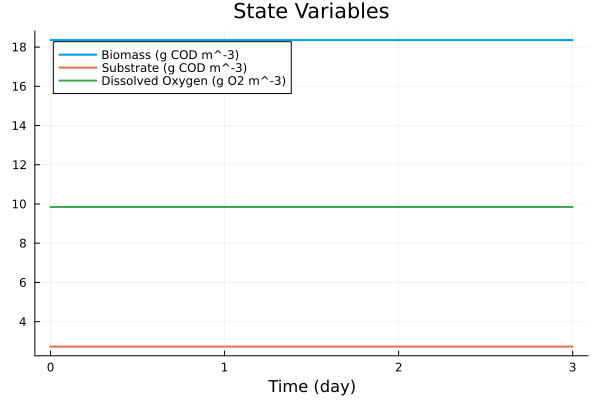

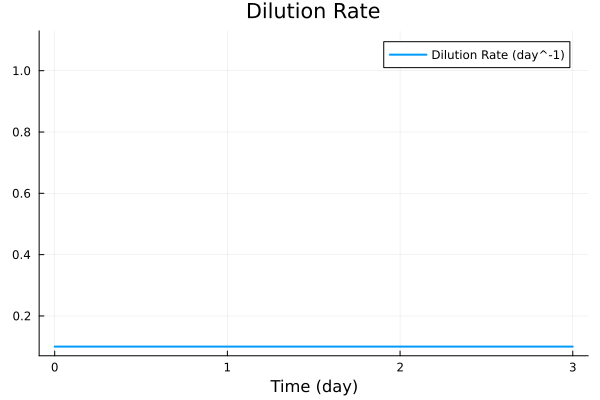

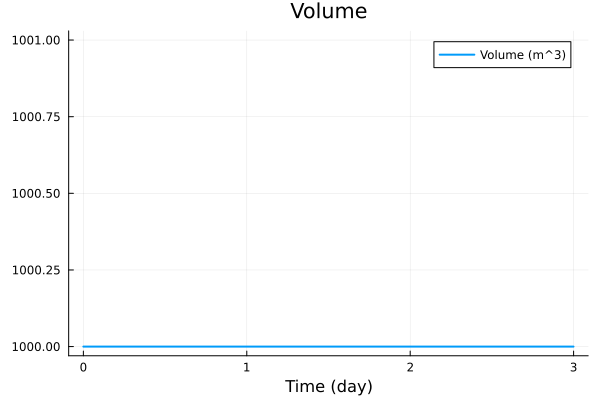

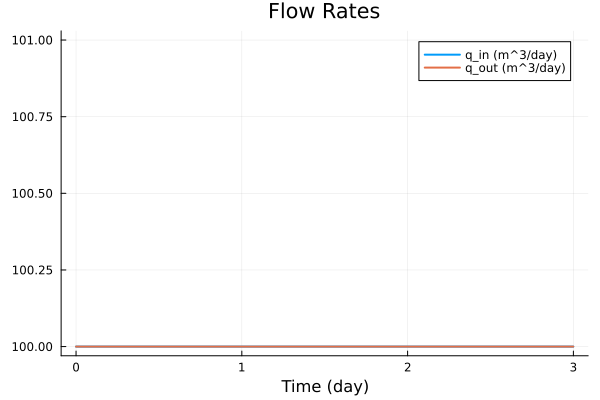

In [ ]:
using JuMP, Ipopt, Plots

case_name = "Bioreactor_RK4"

NT = 3.0 #days
h = 1/1440 #step time in days 
T = Int(NT/h)

model = Model(Ipopt.Optimizer)

# State variables
@variable(model, V[1:T])
@variable(model, Xb[1:T])
@variable(model, Ss[1:T])
@variable(model, So[1:T])


# Inputs
@variable(model, q_in[1:T])
@variable(model, q_out[1:T])

# Dilution rate D = q_in/V (avoids cubic terms)
@variable(model, D[1:T])
@constraint(model, [t=1:T], D[t] * V[t] == q_in[t])

# --- RK4 stages ---
@variable(model, k1_V[2:T]);  @variable(model, k2_V[2:T]); @variable(model, k3_V[2:T]);  @variable(model, k4_V[2:T])
@variable(model, k1_Xb[2:T]); @variable(model, k2_Xb[2:T]); @variable(model, k3_Xb[2:T]); @variable(model, k4_Xb[2:T])
@variable(model, k1_Ss[2:T]); @variable(model, k2_Ss[2:T]); @variable(model, k3_Ss[2:T]); @variable(model, k4_Ss[2:T])
@variable(model, k1_So[2:T]); @variable(model, k2_So[2:T]); @variable(model, k3_So[2:T]); @variable(model, k4_So[2:T])

# --- Parameters ---
mu_max = 6.0  #day^-1
Ks = 20.0 #g COD m^-3
kla = 120 # d^-1
b = 0.62 #day^-1
Y = 0.67 #g cell COD formed (g COD oxidizedx)^-1
So_sat = 10 #g O2 m^-3

# --- Influent ---
Xb_in = 0.0
Ss_in = 200.0
So_in = 2.0


# ODE functions
function mu_monod(Ss)
    return mu_max * Ss / (Ks + Ss)
end

function dVdt(q_in, q_out)
    return q_in - q_out
end

function dXbdt(Xb, Ss, D)
    return D * (Xb_in - Xb) + mu_monod(Ss) * Xb - b * Xb
end

function dSsdt(Xb, Ss, D)
    return D * (Ss_in - Ss) - (1 / Y) * mu_monod(Ss) * Xb
end

function dSodt(Xb, Ss, So, D)
    return D * (So_in - So) + kla*(So_sat - So) - ((1-Y)/Y) * mu_monod(Ss) * Xb - b*Xb
end

# Stage 1: evaluated at t-1
@constraint(model, [t=2:T], k1_V[t]  == h * dVdt(q_in[t-1], q_out[t-1]))
@constraint(model, [t=2:T], k1_Xb[t] == h * dXbdt(Xb[t-1], Ss[t-1], D[t-1]))
@constraint(model, [t=2:T], k1_Ss[t] == h * dSsdt(Xb[t-1], Ss[t-1], D[t-1]))
@constraint(model, [t=2:T], k1_So[t] == h * dSodt(Xb[t-1], Ss[t-1], So[t-1], D[t-1]))

# Stage 2: midpoint using k1
@constraint(model, [t=2:T], k2_V[t]  == h * dVdt(q_in[t-1], q_out[t-1]))
@constraint(model, [t=2:T], k2_Xb[t] == h * dXbdt(Xb[t-1] + k1_Xb[t] / 2, Ss[t-1] + k1_Ss[t] / 2, D[t-1]))
@constraint(model, [t=2:T], k2_Ss[t] == h * dSsdt(Xb[t-1] + k1_Xb[t] / 2, Ss[t-1] + k1_Ss[t] / 2, D[t-1]))
@constraint(model, [t=2:T], k2_So[t] == h * dSodt(Xb[t-1] + k1_Xb[t] / 2, Ss[t-1] + k1_Ss[t] / 2, So[t-1] + k1_So[t] / 2, D[t-1]))

# Stage 3: midpoint using k2
@constraint(model, [t=2:T], k3_V[t]  == h * dVdt(q_in[t-1], q_out[t-1]))
@constraint(model, [t=2:T], k3_Xb[t] == h * dXbdt(Xb[t-1] + k2_Xb[t] / 2, Ss[t-1] + k2_Ss[t] / 2, D[t-1]))
@constraint(model, [t=2:T], k3_Ss[t] == h * dSsdt(Xb[t-1] + k2_Xb[t] / 2, Ss[t-1] + k2_Ss[t] / 2, D[t-1]))
@constraint(model, [t=2:T], k3_So[t] == h * dSodt(Xb[t-1] + k2_Xb[t] / 2, Ss[t-1] + k2_Ss[t] / 2, So[t-1] + k2_So[t] / 2, D[t-1]))

# Stage 4: end using k3
@constraint(model, [t=2:T], k4_V[t]  == h * dVdt(q_in[t-1], q_out[t-1]))
@constraint(model, [t=2:T], k4_Xb[t] == h * dXbdt(Xb[t-1] + k3_Xb[t], Ss[t-1] + k3_Ss[t], D[t-1]))
@constraint(model, [t=2:T], k4_Ss[t] == h * dSsdt(Xb[t-1] + k3_Xb[t], Ss[t-1] + k3_Ss[t], D[t-1]))
@constraint(model, [t=2:T], k4_So[t] == h * dSodt(Xb[t-1] + k3_Xb[t], Ss[t-1] + k3_Ss[t], So[t-1], D[t-1]))

# State updates
@constraint(model, [t=2:T], V[t]  == V[t-1]  + (k1_V[t]  + 2 * k2_V[t]  + 2 * k3_V[t]  + k4_V[t])  / 6)
@constraint(model, [t=2:T], Xb[t] == Xb[t-1] + (k1_Xb[t] + 2 * k2_Xb[t] + 2 * k3_Xb[t] + k4_Xb[t]) / 6)
@constraint(model, [t=2:T], Ss[t] == Ss[t-1] + (k1_Ss[t] + 2 * k2_Ss[t] + 2 * k3_Ss[t] + k4_Ss[t]) / 6)
@constraint(model, [t=2:T], So[t] == So[t-1] + (k1_So[t] + 2 * k2_So[t] + 2 * k3_So[t] + k4_So[t]) / 6)

# Initial conditions
@constraint(model, V[1]  == 1000.0) #m^3
@constraint(model, Xb[1] == 18.357)
@constraint(model, Ss[1] == 2.727)
@constraint(model, So[1] == 9.84)


# Input profiles
@constraint(model, q_in[1:T] .== 100.0)
@constraint(model, q_out[1:T] .== 100.0)

@objective(model, Min, 1) # 1 = simulation, no optimization
optimize!(model)

V_values = value.(V)
Xb_values = value.(Xb)
Ss_values = value.(Ss)
So_values = value.(So)
D_values = value.(D)
q_in_values = value.(q_in)
q_out_values = value.(q_out)